In [ ]:
import os
import sys
from pathlib import Path

repo_root = Path.cwd()
src_root = repo_root / "src"
if src_root.exists() and str(src_root) not in sys.path:
    sys.path.insert(0, str(src_root))

import matplotlib.pyplot as plt
import numpy as np
import sigpy as sp
import torch

from mgrasp_recon import (
    BasisPreparationConfig,
    BasisPreparationWorkflow,
    CoilCalibrationConfig,
    LowResReconConfig,
    SegmentationConfig,
)
from mgrasp_recon.recon_utils import get_traj, infer_kspace_dims, list_slice_files, read_csv_config
from mgrasp_recon.visualization import plot_segmentation_summary


> device  <CUDA Device 0>

Reading configurations from: /home/naiqianluan/DCE-MRI/data/DCE_data/20250827-110742-Gross_MeyerA/RAVE_files/config_subject.csv
Found 1 configurations to process


Processing DCE
  spokes_per_frame: 46
  slice_idx: 47
  slice_inc: 1
  images_per_slab: 96
> Found 96 slice files in //home/naiqianluan/DCE-MRI/data/DCE_data/20250827-110742-Gross_MeyerA/RAVE_files/h5slices_wt_acqT/DCE
> Inferred k-space dimensions from first slice: slices=2, spokes=2220, samples=512, coils=64
> dims: coils=64, spokes=2220, samples=512, N_time=48
  traj shape: (48, 46, 512, 2)

>>> slice 047 | slice48.h5
Loaded raw k-space from //home/naiqianluan/DCE-MRI/data/DCE_data/20250827-110742-Gross_MeyerA/RAVE_files/h5slices_wt_acqT/DCE/slice48.h5
  raw shape: (64, 512, 2220, 2), dtype: float64
  ksp_ri shape: (2, 2220, 512, 64)
ksp_coil shape: (2, 2220, 512, 64)
  k1 shape: (64, 2220, 512)
[get_coil] k-space shape: (64, 2220, 512)
[get_coil] base_res: 256
[get_coil] N_coils: 64
[get_coil] 

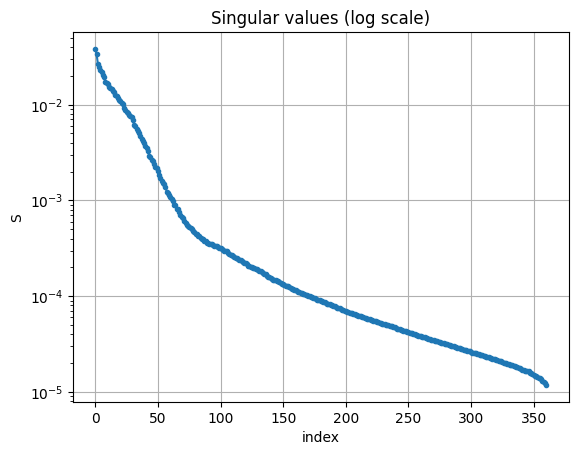

threshold = 0.0007633339
kept = 67 out of 361
Number of kernels kept: 67
before update iteration: 0
current iteration: 1
current iteration: 2
current iteration: 3
current iteration: 4
current iteration: 5
current iteration: 6
current iteration: 7
current iteration: 8
current iteration: 9
current iteration: 10
current iteration: 11
current iteration: 12
current iteration: 13
current iteration: 14
current iteration: 15
current iteration: 16
current iteration: 17
current iteration: 18
current iteration: 19
current iteration: 20
current iteration: 21
current iteration: 22
current iteration: 23
current iteration: 24
current iteration: 25
current iteration: 26
current iteration: 27
current iteration: 28
current iteration: 29
current iteration: 30
current iteration: 31
current iteration: 32
current iteration: 33
current iteration: 34
current iteration: 35
current iteration: 36
current iteration: 37
current iteration: 38
current iteration: 39
current iteration: 40
current iteration: 41
current

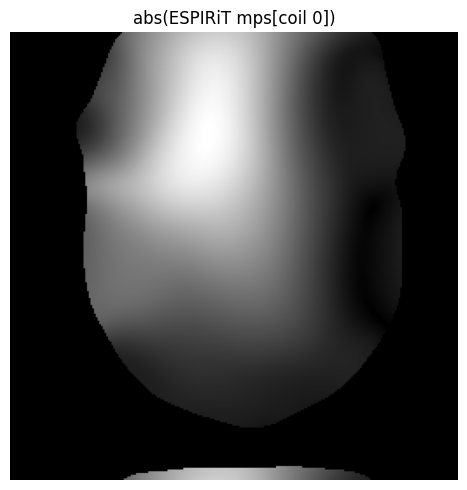

  mps shape: (1, 64, 256, 256)


In [91]:
class Args:
    base_dir = "//home/naiqianluan/DCE-MRI/data/DCE_data/20250827-110742-Gross_MeyerA/RAVE_files/h5slices_wt_acqT/"
    csv_path = "/home/naiqianluan/DCE-MRI/data/DCE_data/20250827-110742-Gross_MeyerA/RAVE_files/config_subject.csv"

args = Args()
subject_id = "Gross_MeyerA"

device = sp.Device(0 if torch.cuda.is_available() else -1)
print("> device ", device)
print()
print(f"Reading configurations from: {args.csv_path}")
configs = read_csv_config(args.csv_path)
print(f"Found {len(configs)} configurations to process")
print()

for config in configs:
    args.hop_id = config["hop_id"]
    args.spokes_per_frame = 46
    args.slice_idx = 47
    args.slice_inc = 1
    args.images_per_slab = config["images_per_slab"]

    print("=" * 60)
    print(f"Processing {args.hop_id}")
    print("=" * 60)
    print(f"  spokes_per_frame: {args.spokes_per_frame}")
    print(f"  slice_idx: {args.slice_idx}")
    print(f"  slice_inc: {args.slice_inc}")
    print(f"  images_per_slab: {args.images_per_slab}")

    hop_dir = os.path.join(args.base_dir, args.hop_id)
    if not os.path.exists(hop_dir):
        raise FileNotFoundError(f"Directory not found: {hop_dir}")

    slice_files = list_slice_files(hop_dir)
    n_slices_total = len(slice_files)
    print(f"> Found {n_slices_total} slice files in {hop_dir}")
    n_coils, n_samples, n_spokes, n_slices = infer_kspace_dims(slice_files[0])
    print(
        f"> Inferred k-space dimensions from first slice: "
        f"slices={n_slices}, spokes={n_spokes}, samples={n_samples}, coils={n_coils}"
    )
    base_res = n_samples // 2
    n_time = n_spokes // args.spokes_per_frame
    if n_time <= 0:
        raise ValueError(
            f"n_time={n_time}. Check spokes_per_frame={args.spokes_per_frame} vs n_spokes={n_spokes}"
        )

    traj = get_traj(N_spokes=args.spokes_per_frame, N_time=n_time, base_res=base_res, gind=1)
    print(f"> dims: coils={n_coils}, spokes={n_spokes}, samples={n_samples}, n_time={n_time}")
    print(f"  traj shape: {traj.shape}")

    s = 47
    sf = slice_files[s]
    print()
    print(f">>> slice {str(s).zfill(3)} | {os.path.basename(sf)}")

    basis_workflow = BasisPreparationWorkflow(
        BasisPreparationConfig(
            spokes_per_frame=args.spokes_per_frame,
            lowres=LowResReconConfig(
                img_shape=(512, 512),
                ns_low=512,
                method="adjoint",
                normalize=False,
                return_complex=False,
                use_ramp_filter=True,
                verbose=True,
            ),
            coil=CoilCalibrationConfig(thresh=0.02, verbose=True),
            segmentation=SegmentationConfig(
                frame_time_sec=3.8,
                n_baseline=5,
                early_duration_sec=120,
                brain_percentile=60,
                core_erosion_iters=12,
                roi_erosion_iters=8,
                enhancement_percentile=75,
                cleanup_min_size=10,
            ),
            nbasis=5,
            remove_mean=True,
            use_segmented_basis=True,
        )
    )


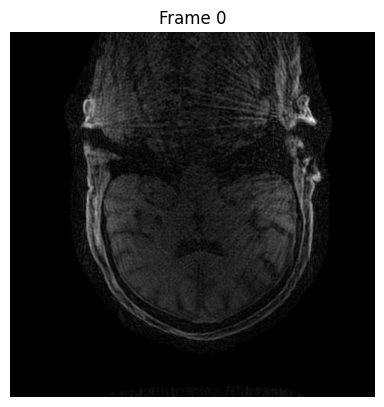

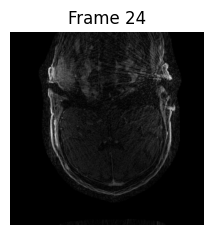

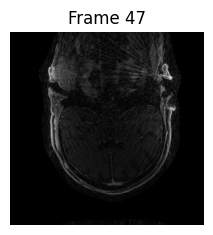

In [92]:
step1_result = basis_workflow.run(slice_files=slice_files, slice_idx=s, traj=traj)
img_init = step1_result.img_lowres
mps = step1_result.mps
seg = step1_result.segmentation
vascular_basis = step1_result.vascular_basis
tissue_basis = step1_result.tissue_basis

print("  mps shape:", np.asarray(sp.to_device(mps, sp.cpu_device)).shape)
print("  img_init shape:", img_init.shape)

plt.figure(figsize=(12, 4))
for i, tt in enumerate([0, img_init.shape[0] // 2, img_init.shape[0] - 1]):
    plt.subplot(1, 3, i + 1)
    plt.imshow(np.abs(img_init[tt]), cmap="gray")
    plt.title(f"Frame {tt}")
    plt.axis("off")
plt.tight_layout()
plt.show()


brain mask thr: 0.0011312945280224085
enh thr: 1.713064432144165
brain_mask voxels: 128258
brain_core_mask voxels: 109922
brain_ring_mask voxels: 18336
pca_roi_mask voxels: 98943
vascular voxels: 23699
tissue voxels: 75244


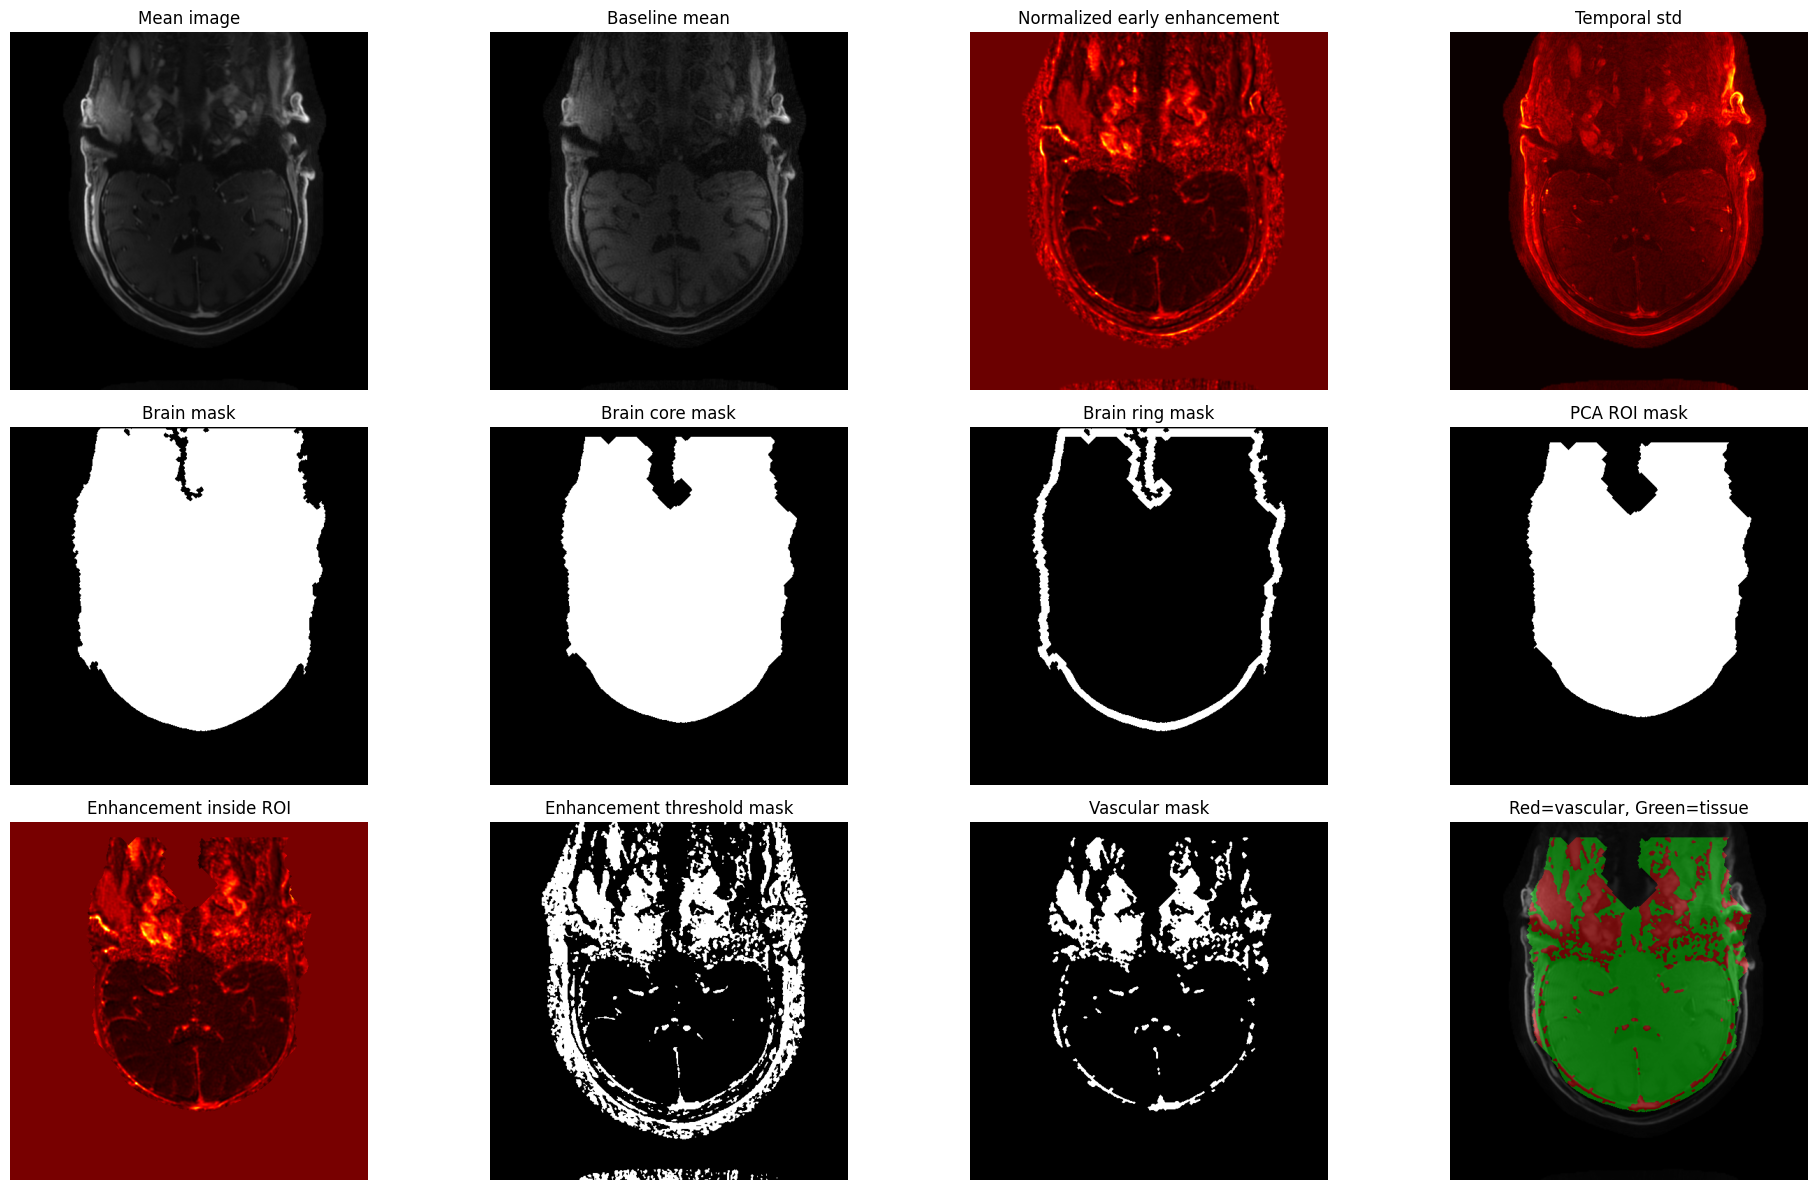

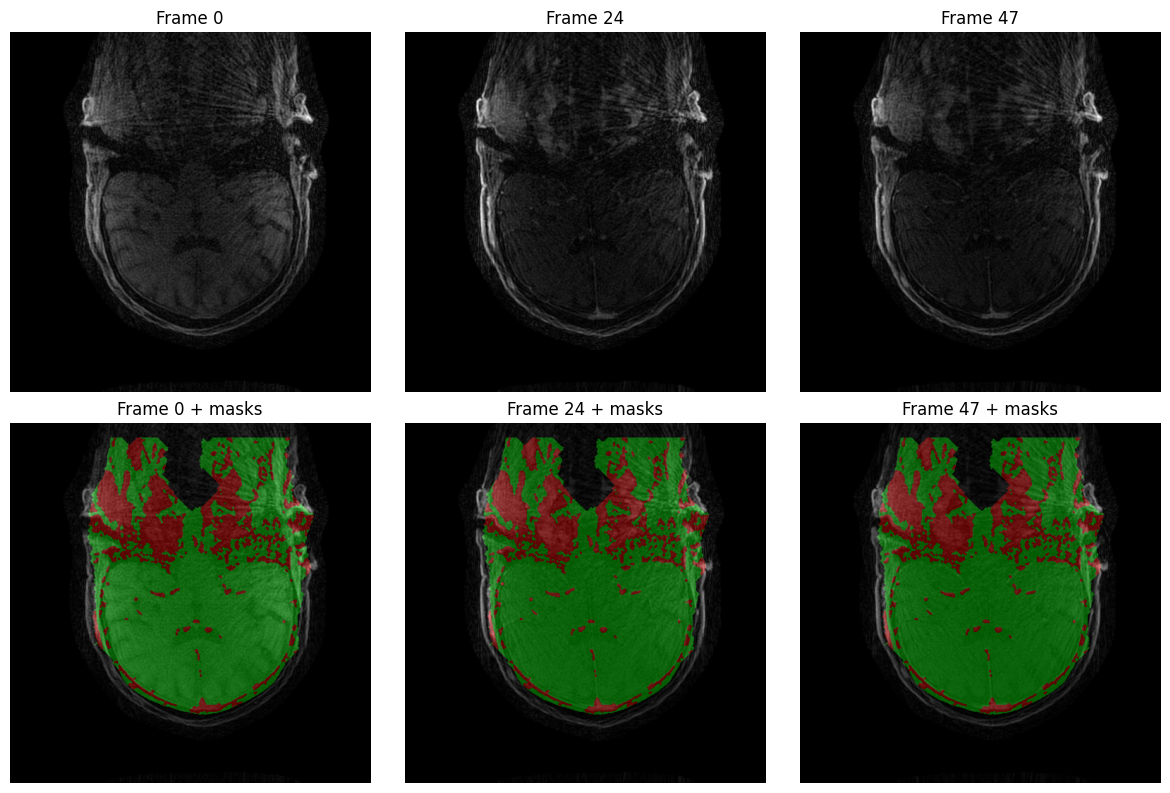

In [93]:
vascular_mask = seg.vascular_mask
tissue_mask = seg.tissue_mask
pca_roi_mask = seg.pca_roi_mask

plot_segmentation_summary(
    mean_img=seg.mean_img,
    baseline_mean=seg.baseline_mean,
    norm_early_enh=seg.norm_early_enh,
    std_img=seg.std_img,
    brain_mask=seg.brain_mask,
    brain_core_mask=seg.brain_core_mask,
    brain_ring_mask=seg.brain_ring_mask,
    pca_roi_mask=seg.pca_roi_mask,
    vascular_mask=seg.vascular_mask,
    tissue_mask=seg.tissue_mask,
    enhancement_threshold=seg.enhancement_threshold,
)
plt.show()


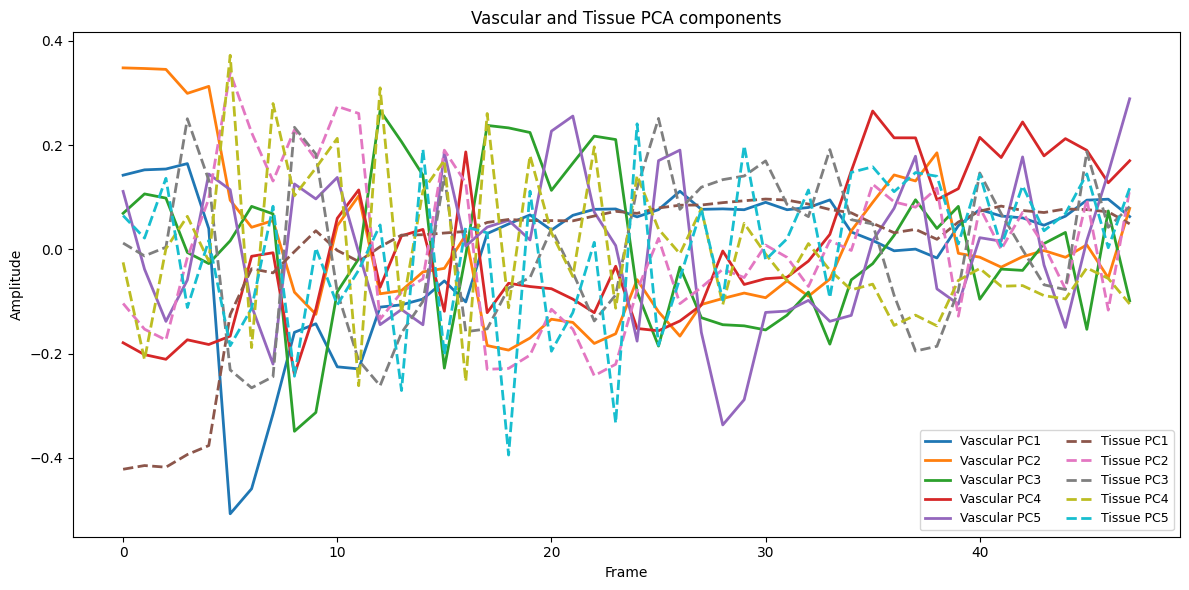

In [104]:
K_show = 5

plt.figure(figsize=(12, 6))
for k in range(min(K_show, vascular_basis.shape[1])):
    plt.plot(vascular_basis[:, k], linewidth=2, label=f"Vascular PC{k + 1}")
for k in range(min(K_show, tissue_basis.shape[1])):
    plt.plot(tissue_basis[:, k], linestyle="--", linewidth=2, label=f"Tissue PC{k + 1}")

plt.title("Vascular and Tissue PCA components")
plt.xlabel("Frame")
plt.ylabel("Amplitude")
plt.legend(ncol=2, fontsize=9)
plt.tight_layout()
plt.show()


vascular eigenvalues: [8.57382117e-06 5.11144853e-06 3.99883206e-06 1.58632019e-06
 1.36276520e-06 1.33425647e-06 1.14669161e-06 1.00423384e-06
 9.54255558e-07 9.09889658e-07]
tissue eigenvalues: [3.40089244e-06 1.24488168e-06 1.14118005e-06 7.85891782e-07
 7.67070013e-07 6.84676601e-07 6.44815505e-07 6.30767552e-07
 5.87860592e-07 5.80295693e-07]


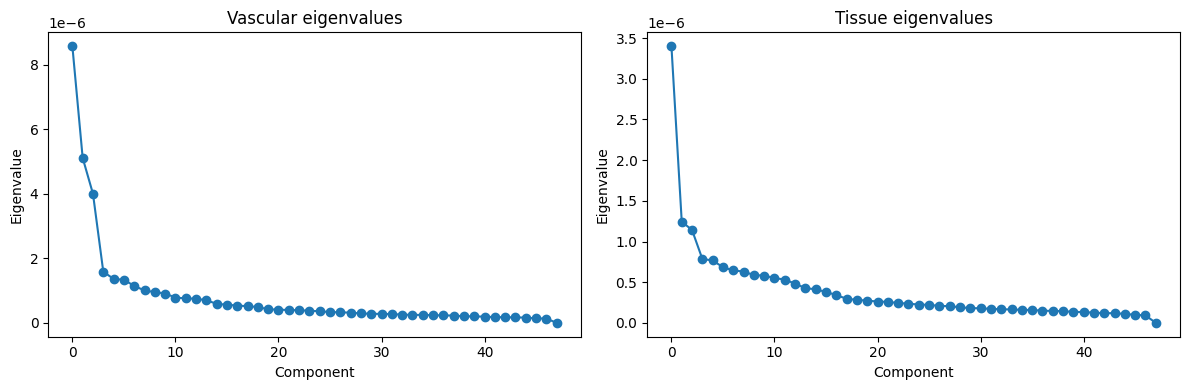

In [100]:
vascular_energy = np.sum(vascular_basis ** 2, axis=0)
tissue_energy = np.sum(tissue_basis ** 2, axis=0)

print("vascular basis energy:", vascular_energy[:10])
print("tissue basis energy:", tissue_energy[:10])

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(vascular_energy, "o-")
plt.title("Vascular basis energy")
plt.xlabel("Component")
plt.ylabel("Energy")

plt.subplot(1, 2, 2)
plt.plot(tissue_energy, "o-")
plt.title("Tissue basis energy")
plt.xlabel("Component")
plt.ylabel("Energy")

plt.tight_layout()
plt.show()


In [106]:
basis = np.concatenate([vascular_basis[:, :3], tissue_basis[:, :3]], axis=1)
out_path = "/home/naiqianluan/DCE-MRI/data/test-pro-grasp/fbasis.h5"
basis_workflow.save_basis(basis, out_path)
print(f"Saved basis to: {out_path}")


Saved basis to: /home/naiqianluan/DCE-MRI/data/test-pro-grasp/fbasis.h5
in-memory basis shape (T, K): (48, 6)
stored H5 dataset shape (K, T): (6, 48)


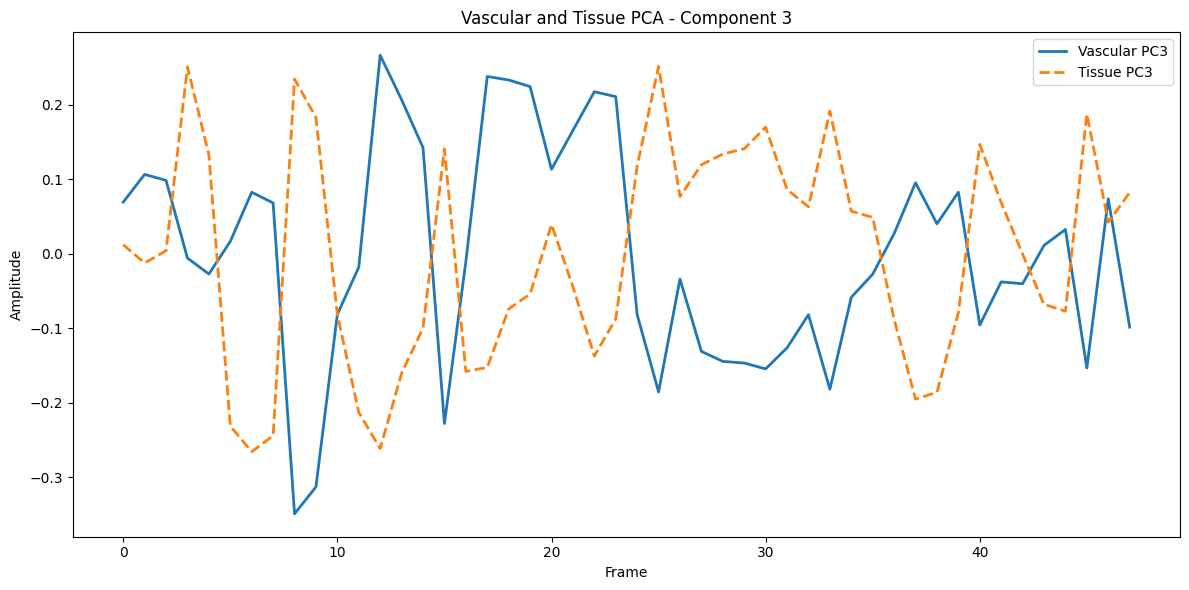

In [ ]:
# plt.figure(figsize=(12, 6))

# k = 2  

# # Vascular
# if vascular_basis.shape[1] > k:
#     plt.plot(vascular_basis[:, k], linewidth=2, label="Vascular PC3")

# # Tissue
# if tissue_basis.shape[1] > k:
#     plt.plot(tissue_basis[:, k], linestyle="--", linewidth=2, label="Tissue PC3")

# plt.title("Vascular and Tissue PCA - Component 3")
# plt.xlabel("Frame")
# plt.ylabel("Amplitude")
# plt.legend()
# plt.tight_layout()
# plt.show()